<a href="https://colab.research.google.com/github/venkataraman-at/Trading_Smarter/blob/main/RL_PROJECT_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA COLLECTION

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import os
from google.colab import files

def download_and_save_data(stock_symbol, filename):
    """Downloads one month of stock data and saves it to a CSV file."""
    end_date = datetime.now()  # Today: April 10, 2025
    start_date = end_date - timedelta(days=60)
    # Ensure dates are in correct format
    start_date_str = start_date.strftime('%Y-%m-%d')
    end_date_str = end_date.strftime('%Y-%m-%d')

    # Download stock data
    stock_data = yf.download(stock_symbol, start=start_date_str, end=end_date_str)

    # Inspect the columns to understand their structure
    print("Columns:", stock_data.columns)

    # If there is a multi-level column index, flatten it
    if isinstance(stock_data.columns, pd.MultiIndex):
        stock_data.columns = ['_'.join(col).strip() for col in stock_data.columns.values]

    # Check the first few rows to verify the structure
    print(stock_data.head())

    # Now select 'Close' and 'Volume' columns (adjust names if necessary based on inspection)
    if 'Close' in stock_data.columns and 'Volume' in stock_data.columns:
        stock_data = stock_data[['Close', 'Volume']]
    else:
        # Handle cases where column names are different due to formatting
        close_col = [col for col in stock_data.columns if 'close' in col.lower()]
        volume_col = [col for col in stock_data.columns if 'volume' in col.lower()]

        if close_col and volume_col:
            stock_data = stock_data[[close_col[0], volume_col[0]]]
            stock_data.rename(columns={close_col[0]: 'Close', volume_col[0]: 'Volume'}, inplace=True)
        else:
            raise KeyError("Could not find 'Close' or 'Volume' columns in the data.")

    # Calculate the 10-day Moving Average
    stock_data['10_day_MA'] = stock_data['Close'].rolling(window=10).mean()

    # Calculate the daily price change (percentage change from the previous close)
    stock_data['Price Change'] = stock_data['Close'].pct_change()

    # Calculate the reward (price change minus transaction cost penalty of 0.1%)
    stock_data['Reward'] = stock_data['Price Change'] - 0.001  # Assuming a 0.1% transaction cost

    # Drop rows with NaN values generated from rolling or percentage change calculation
    stock_data.dropna(inplace=True)

    # Verify the results
    print(stock_data.head())

    # Save the data to the Colab environment
    stock_data.to_csv(filename, index=True)
    print(f"Saved stock data to {filename} in the Colab environment")

    return filename  # Return the filename


if __name__ == '__main__':
    stock_symbol = input("Enter the stock symbol (e.g., AAPL): ")
    filename = f"{stock_symbol}.csv"
    filename = download_and_save_data(stock_symbol, filename)
    print(f"Data saved to: {filename}")

    # Save the stock symbol for use in Q-learning cell
    with open("stock_symbol.txt", "w") as f:
        f.write(stock_symbol)

    print(f"Stock symbol: {stock_symbol}")




Enter the stock symbol (e.g., AAPL): MSFT


[*********************100%***********************]  1 of 1 completed

Columns: MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])
            Close_MSFT   High_MSFT    Low_MSFT   Open_MSFT  Volume_MSFT
Date                                                                   
2025-02-21  408.209991  418.049988  407.890015  417.339996     27524800
2025-02-24  404.000000  409.369995  399.320007  408.510010     26443700
2025-02-25  397.899994  401.920013  396.700012  401.100006     29387400
2025-02-26  399.730011  403.600006  394.250000  398.010010     19619000
2025-02-27  392.529999  405.739990  392.170013  401.269989     21127400
                 Close    Volume   10_day_MA  Price Change    Reward
Date                                                                
2025-03-06  396.890015  23304600  397.436996     -0.010299 -0.011299
2025-03-07  393.309998  22034100  395.946997     -0.009020 -0.010020
2025-03-10  

In [ ]:
files.download(filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ENVIRONMENT

In [ ]:
import pandas as pd
import numpy as np

class StockTradingEnv:
    def __init__(self, data_file):
        self.data = pd.read_csv(data_file, index_col='Date')  # Assuming 'Date' is your index column
        self.current_step = 0
        self.balance = 10000  # Starting balance
        self.shares_held = 0
        self.total_profit = 0
        self.buy_price = 0  # Store the buy price

    def reset(self):
        self.current_step = 0
        self.balance = 10000
        self.shares_held = 0
        self.total_profit = 0
        self.buy_price = 0  # Reset buy price
        return self.get_state()

    def get_state(self):
        # Define the state representation (e.g., current price, volume, moving average)
        state = self.data.iloc[self.current_step][['Close', 'Volume', '10_day_MA']].values
        return state

    def step(self, action):
        # Define actions (e.g., 0: hold, 1: buy, 2: sell)
        # Update balance, shares_held, and total_profit based on the action
        current_price = self.data.iloc[self.current_step]['Close']

        if action == 1:  # Buy
            if self.balance > 0:  # Check if there's enough balance to buy
                affordable_shares = int(self.balance / current_price)
                self.shares_held += affordable_shares
                self.balance -= affordable_shares * current_price
                self.buy_price = current_price  # Store the buy price
        elif action == 2:  # Sell
            if self.shares_held > 0:
                self.balance += self.shares_held * current_price
                self.total_profit += (current_price - self.buy_price) * self.shares_held  # Calculate profit
                self.shares_held = 0
                self.buy_price = 0  # Reset buy price

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        reward = self.calculate_reward()

        return self.get_state(), reward, done, {}  # info dictionary can be empty

    def calculate_reward(self):
        # Simple reward based on price change
        current_price = self.data.iloc[self.current_step]['Close']
        if self.current_step > 0:
            previous_price = self.data.iloc[self.current_step - 1]['Close']
            price_change = (current_price - previous_price) / previous_price
            return price_change  # You can adjust this reward calculation
        else:
            return 0  # No reward for the first step

    def render(self):
        # Optionally, print or visualize the current state
        print(f"Step: {self.current_step}, Balance: {self.balance}, Shares Held: {self.shares_held}, Total Profit: {self.total_profit}")

Q LEARNING

TRANSACTION COST: 0.1%

Using stock data file: MSFT.csv

First 5 rows of stock data loaded into the environment:
                 Close    Volume   10_day_MA  Price Change    Reward
Date                                                                
2025-03-06  396.890015  23304600  397.436996     -0.010299 -0.011299
2025-03-07  393.309998  22034100  395.946997     -0.009020 -0.010020
2025-03-10  380.160004  32840100  393.562997     -0.033434 -0.034434
2025-03-11  380.450012  30380200  391.817999      0.000763 -0.000237
2025-03-12  383.269989  24253600  390.171997      0.007412  0.006412

Training with 0.1% Transaction Cost
Episode 0, Exploration Rate: 0.9938
Episode 500, Exploration Rate: 0.0448
Episode 1000, Exploration Rate: 0.0020

Testing with 0.1% Transaction Cost
Step 1: Price=393.31, Balance=10000.00, Shares=0, Portfolio Value=10000.00, Profit=0.00
Step 2: Price=380.16, Balance=10000.00, Shares=0, Portfolio Value=10000.00, Profit=0.00
Step 3: Price=380.45, Balance=10000.00, Shares=0, Portfolio Value=

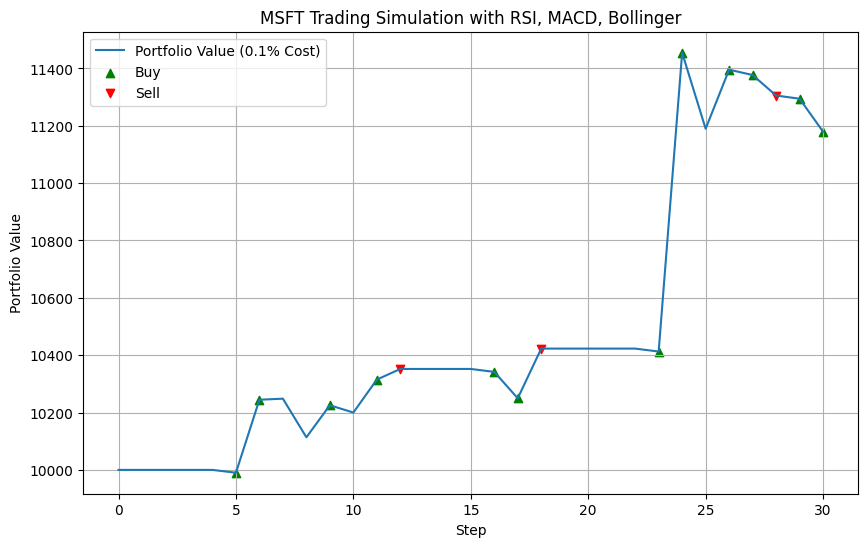

In [ ]:
import gym
from gym import spaces
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# ===== Read stock symbol saved from Cell 1 =====
with open("stock_symbol.txt", "r") as f:
    stock_symbol = f.read().strip()

filename = f"{stock_symbol}.csv"
print(f"Using stock data file: {filename}")

# ===== StockTradingEnv Definition =====
class StockTradingEnv(gym.Env):
    def __init__(self, data_file, transaction_cost=0.001):
        super(StockTradingEnv, self).__init__()
        self.data = pd.read_csv(data_file, index_col='Date')

        print("\nFirst 5 rows of stock data loaded into the environment:")
        print(self.data.head())

        # Add RSI feature
        delta = self.data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        self.data['RSI'] = 100 - (100 / (1 + rs))
        self.data['RSI'] = self.data['RSI'].fillna(50)

        # Add MACD feature
        ema12 = self.data['Close'].ewm(span=12, adjust=False).mean()
        ema26 = self.data['Close'].ewm(span=26, adjust=False).mean()
        self.data['MACD'] = ema12 - ema26
        self.data['MACD'] = self.data['MACD'].fillna(0)

        # Add Bollinger Bands
        rolling_mean = self.data['Close'].rolling(window=20).mean()
        rolling_std = self.data['Close'].rolling(window=20).std()
        self.data['Bollinger'] = (self.data['Close'] - (rolling_mean + 2 * rolling_std)) / self.data['Close']
        self.data['Bollinger'] = self.data['Bollinger'].fillna(0)

        # Ensure required columns exist and are float32
        required_columns = ['Close', 'Volume', '10_day_MA', 'RSI', 'MACD', 'Bollinger']
        if not all(col in self.data.columns for col in required_columns):
            raise ValueError(f"CSV must contain {required_columns}. Found: {self.data.columns.tolist()}")
        self.data[required_columns] = self.data[required_columns].astype(np.float32)

        self.transaction_cost = transaction_cost
        self.current_step = 0
        self.balance = 10000
        self.shares_held = 0
        self.total_profit = 0
        self.buy_price = 0
        self.action_space = spaces.Discrete(3)  # 0: Buy, 1: Sell, 2: Hold
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)

    def reset(self):
        self.current_step = 0
        self.balance = 10000
        self.shares_held = 0
        self.total_profit = 0
        self.buy_price = 0
        return self.get_state()

    def get_state(self):
        return self.data.iloc[self.current_step][['Close', 'Volume', '10_day_MA', 'RSI', 'MACD', 'Bollinger']].values

    def step(self, action):
        current_price = self.data['Close'].iloc[self.current_step]

        # Calculate previous portfolio value
        previous_price = self.data['Close'].iloc[self.current_step - 1] if self.current_step > 0 else current_price
        previous_portfolio_value = self.balance + self.shares_held * previous_price

        if action == 0:  # Buy
            shares_to_buy = int(self.balance // current_price)
            cost = shares_to_buy * current_price * (1 + self.transaction_cost)
            if cost <= self.balance and shares_to_buy > 0:
                self.balance -= cost
                self.shares_held += shares_to_buy
                self.buy_price = current_price

        elif action == 1 and self.shares_held > 0:  # Sell
            revenue = self.shares_held * current_price * (1 - self.transaction_cost)
            profit = revenue - (self.shares_held * self.buy_price)
            self.balance += revenue
            self.total_profit += profit
            self.shares_held = 0
            self.buy_price = 0

        # No else needed explicitly for Hold (action == 2), as no balance/shares change

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        # Calculate current portfolio value after actions
        current_portfolio_value = self.balance + self.shares_held * current_price

        # Reward is the percentage change in portfolio value from previous step
        reward = (current_portfolio_value - previous_portfolio_value) / previous_portfolio_value

        return self.get_state(), reward, done, {}


    def render(self, mode='human', **kwargs):
        current_price = self.data['Close'].iloc[self.current_step]
        portfolio_value = self.balance + self.shares_held * current_price
        print(f"Step {self.current_step}: Price={current_price:.2f}, Balance={self.balance:.2f}, "
              f"Shares={self.shares_held}, Portfolio Value={portfolio_value:.2f}, Profit={self.total_profit:.2f}")

# ===== Q-Learning Agent Definition =====
class QLearningAgent:
    def __init__(self, action_size, state_size, learning_rate=0.1, discount_factor=0.95,
                 exploration_rate=1.0, exploration_decay_rate=0.9995):
        self.action_size = action_size
        self.state_size = state_size
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay_rate = exploration_decay_rate
        self.q_table = {}

    def discretize_state(self, state):
        price_bin = int(state[0] // 5)   # less sensitive
        volume_bin = int(state[1] // 1e6)  # reduce bins
        ma_bin = int(state[2] // 5)      # less sensitive
        rsi_bin = int(state[3] // 10)    # 10 bins (RSI: 0-100)
        macd_bin = int(np.clip(state[4], -2, 2))  # MACD simplified
        boll_bin = int(np.clip(state[5], -1, 1) * 10)  # 20 bins

        return (price_bin, volume_bin, ma_bin, rsi_bin, macd_bin, boll_bin)


    def act(self, state):
        state_index = self.discretize_state(state)
        if state_index not in self.q_table:
            self.q_table[state_index] = np.zeros(self.action_size)
        if random.uniform(0, 1) < self.exploration_rate:
            return random.randrange(self.action_size)
        return np.argmax(self.q_table[state_index])

    def learn(self, state, action, reward, next_state):
        state_index = self.discretize_state(state)
        next_state_index = self.discretize_state(next_state)

        if state_index not in self.q_table:
            self.q_table[state_index] = np.zeros(self.action_size)
        if next_state_index not in self.q_table:
            self.q_table[next_state_index] = np.zeros(self.action_size)

        best_next_action = np.argmax(self.q_table[next_state_index])
        q_update = (reward + self.discount_factor * self.q_table[next_state_index][best_next_action] -
                    self.q_table[state_index][action])
        self.q_table[state_index][action] += self.learning_rate * q_update
        self.exploration_rate *= self.exploration_decay_rate

# ===== Initialize Environment and Agent =====
env = StockTradingEnv(data_file=filename, transaction_cost=0.001)
agent = QLearningAgent(action_size=env.action_space.n,
                       state_size=100000,
                       exploration_decay_rate=0.9998)

# ===== Training Phase =====
print("\nTraining with 0.1% Transaction Cost")
for episode in range(1500):
    state = env.reset()
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        agent.learn(state, action, reward, next_state)
        state = next_state
    if episode % 500 == 0:
        print(f"Episode {episode}, Exploration Rate: {agent.exploration_rate:.4f}")

# ===== Testing Phase =====
print("\nTesting with 0.1% Transaction Cost")
state = env.reset()
env.total_profit = 0  # Reset profit for testing
done = False
portfolio_values = []
trades = []
trade_profits = []
last_buy_price = None

while not done:
    action = agent.act(state)
    current_price = env.data['Close'].iloc[env.current_step]

    if action == 0:
        trades.append(('Buy', env.current_step, current_price))
        last_buy_price = current_price
    elif action == 1 and env.shares_held > 0:
        trades.append(('Sell', env.current_step, current_price))
        profit = (current_price * (1 - env.transaction_cost) - last_buy_price * (1 + env.transaction_cost)) * env.shares_held
        trade_profits.append(profit)
        last_buy_price = None

    next_state, reward, done, _ = env.step(action)
    portfolio_value = env.balance + env.shares_held * current_price
    portfolio_values.append(portfolio_value)

    env.render()
    state = next_state

final_profit = portfolio_values[-1] - 10000
num_trades = len([t for t in trades if t[0] == 'Sell']) * 2
wins = sum(1 for p in trade_profits if p > 0)
losses = sum(1 for p in trade_profits if p <= 0)
win_loss_ratio = wins / (wins + losses) if (wins + losses) > 0 else 0

print(f"\n0.1% Transaction Cost - Final Portfolio Value: {portfolio_values[-1]:.2f}, True Profit: {final_profit:.2f}, Number of Trades: {num_trades}")
print(f"Cumulative Trade Profit (excluding unrealized): {env.total_profit:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio:.2%}")

# ===== Plot Results =====
plt.figure(figsize=(10, 6))
plt.plot(portfolio_values, label='Portfolio Value (0.1% Cost)')
buy_steps = [t[1] for t in trades if t[0] == 'Buy']
sell_steps = [t[1] for t in trades if t[0] == 'Sell']
plt.scatter(buy_steps, [portfolio_values[s] for s in buy_steps], color='green', label='Buy', marker='^')
plt.scatter(sell_steps, [portfolio_values[s] for s in sell_steps], color='red', label='Sell', marker='v')
plt.xlabel('Step')
plt.ylabel('Portfolio Value')
plt.title(f'{stock_symbol} Trading Simulation with RSI, MACD, Bollinger')
plt.legend()
plt.grid()
plt.show()

TRANSACTION COST: 0.5%


First 5 rows of stock data loaded into the environment:
                 Close    Volume   10_day_MA  Price Change    Reward
Date                                                                
2025-03-06  396.890015  23304600  397.436996     -0.010299 -0.011299
2025-03-07  393.309998  22034100  395.946997     -0.009020 -0.010020
2025-03-10  380.160004  32840100  393.562997     -0.033434 -0.034434
2025-03-11  380.450012  30380200  391.817999      0.000763 -0.000237
2025-03-12  383.269989  24253600  390.171997      0.007412  0.006412

Training with 0.5% Transaction Cost
Episode 0, Exploration Rate: 0.9938
Episode 500, Exploration Rate: 0.0448
Episode 1000, Exploration Rate: 0.0020

Testing with 0.5% Transaction Cost
Step 1: Price=393.31, Balance=10000.00, Shares=0, Portfolio Value=10000.00, Profit=0.00
Step 2: Price=380.16, Balance=10000.00, Shares=0, Portfolio Value=10000.00, Profit=0.00
Step 3: Price=380.45, Balance=10000.00, Shares=0, Portfolio Value=10000.00, Profit=0.00
Step 4: Pr

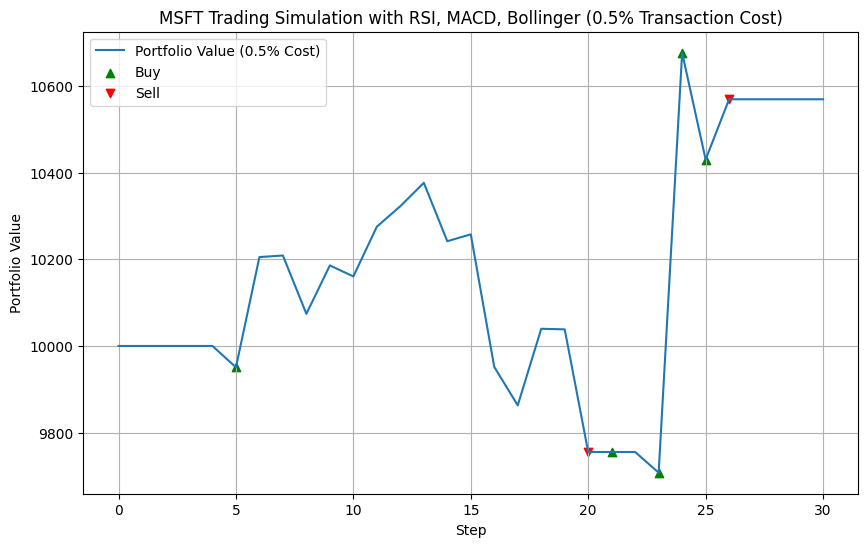

In [ ]:
# ===== Initialize Environment with 0.5% Transaction Cost and Agent =====
env_high_cost = StockTradingEnv(data_file=filename, transaction_cost=0.005)
agent_high_cost = QLearningAgent(action_size=env_high_cost.action_space.n,
                                 state_size=100000,
                                 exploration_decay_rate=0.9998)

# ===== Training Phase =====
print("\nTraining with 0.5% Transaction Cost")
for episode in range(1500):
    state = env_high_cost.reset()
    done = False
    while not done:
        action = agent_high_cost.act(state)
        next_state, reward, done, _ = env_high_cost.step(action)
        agent_high_cost.learn(state, action, reward, next_state)
        state = next_state
    if episode % 500 == 0:
        print(f"Episode {episode}, Exploration Rate: {agent_high_cost.exploration_rate:.4f}")

# ===== Testing Phase =====
print("\nTesting with 0.5% Transaction Cost")
state = env_high_cost.reset()
env_high_cost.total_profit = 0  # Reset profit for testing
done = False
portfolio_values_high = []
trades_high = []
trade_profits_high = []
last_buy_price_high = None

while not done:
    action = agent_high_cost.act(state)
    current_price = env_high_cost.data['Close'].iloc[env_high_cost.current_step]

    if action == 0:
        trades_high.append(('Buy', env_high_cost.current_step, current_price))
        last_buy_price_high = current_price
    elif action == 1 and env_high_cost.shares_held > 0:
        trades_high.append(('Sell', env_high_cost.current_step, current_price))
        profit = (current_price * (1 - env_high_cost.transaction_cost) - last_buy_price_high * (1 + env_high_cost.transaction_cost)) * env_high_cost.shares_held
        trade_profits_high.append(profit)
        last_buy_price_high = None

    next_state, reward, done, _ = env_high_cost.step(action)
    portfolio_value = env_high_cost.balance + env_high_cost.shares_held * current_price
    portfolio_values_high.append(portfolio_value)

    env_high_cost.render()
    state = next_state

final_profit_high = portfolio_values_high[-1] - 10000
num_trades_high = len([t for t in trades_high if t[0] == 'Sell']) * 2
wins_high = sum(1 for p in trade_profits_high if p > 0)
losses_high = sum(1 for p in trade_profits_high if p <= 0)
win_loss_ratio_high = wins_high / (wins_high + losses_high) if (wins_high + losses_high) > 0 else 0

print(f"\n0.5% Transaction Cost - Final Portfolio Value: {portfolio_values_high[-1]:.2f}, True Profit: {final_profit_high:.2f}, Number of Trades: {num_trades_high}")
print(f"Cumulative Trade Profit (excluding unrealized): {env_high_cost.total_profit:.2f}")
print(f"Win/Loss Ratio: {win_loss_ratio_high:.2%}")

# ===== Plot Results =====
plt.figure(figsize=(10, 6))
plt.plot(portfolio_values_high, label='Portfolio Value (0.5% Cost)')
buy_steps_high = [t[1] for t in trades_high if t[0] == 'Buy']
sell_steps_high = [t[1] for t in trades_high if t[0] == 'Sell']
plt.scatter(buy_steps_high, [portfolio_values_high[s] for s in buy_steps_high], color='green', label='Buy', marker='^')
plt.scatter(sell_steps_high, [portfolio_values_high[s] for s in sell_steps_high], color='red', label='Sell', marker='v')
plt.xlabel('Step')
plt.ylabel('Portfolio Value')
plt.title(f'{stock_symbol} Trading Simulation with RSI, MACD, Bollinger (0.5% Transaction Cost)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
#Transaction cost: 0.1%
final_portfolio_value = portfolio_values[-1]
portfolio_return = (final_portfolio_value - 10000) / 10000
profitable_trades = sum(1 for p in trade_profits if p > 0)
win_loss_ratio = profitable_trades / len(trade_profits) if len(trade_profits) > 0 else 0
max_drawdown = max([max(portfolio_values[:i+1]) - min(portfolio_values[i:]) for i in range(len(portfolio_values))]) / 10000

print(f"\n0.1% Transaction Cost - Final Profit: {final_profit:.2f}, Number of Trades: {num_trades}")
print(f"Portfolio Return: {portfolio_return:.2%}, Win/Loss Ratio: {win_loss_ratio:.2%}, Max Drawdown: {max_drawdown:.2%}")



0.1% Transaction Cost - Final Profit: 1179.39, Number of Trades: 6
Portfolio Return: 11.79%, Win/Loss Ratio: 66.67%, Max Drawdown: 2.75%


In [ ]:
# Transaction cost: 0.5%
final_portfolio_value = portfolio_values_high[-1]
portfolio_return = (final_portfolio_value - 10000) / 10000
profitable_trades_high = sum(1 for p in trade_profits_high if p > 0)
win_loss_ratio_high = profitable_trades_high / len(trade_profits_high) if len(trade_profits_high) > 0 else 0
max_drawdown_high = max([max(portfolio_values_high[:i+1]) - min(portfolio_values_high[i:]) for i in range(len(portfolio_values_high))]) / 10000

print(f"\n0.5% Transaction Cost - Final Profit: {final_profit_high:.2f}, Number of Trades: {num_trades_high}")
print(f"Portfolio Return: {portfolio_return:.2%}, Win/Loss Ratio: {win_loss_ratio_high:.2%}, Max Drawdown: {max_drawdown_high:.2%}")


0.5% Transaction Cost - Final Profit: 569.82, Number of Trades: 4
Portfolio Return: 5.70%, Win/Loss Ratio: 50.00%, Max Drawdown: 6.70%


In [ ]:
#Sharpe ratio for 0.1%
daily_returns = [(portfolio_values[i] - portfolio_values[i-1]) / portfolio_values[i-1] for i in range(1, len(portfolio_values))]
avg_daily_return = np.mean(daily_returns) if daily_returns else 0
std_daily_return = np.std(daily_returns) if daily_returns else 0
risk_free_rate = 0.02 / 365  # Daily risk-free rate
sharpe_ratio = (avg_daily_return - risk_free_rate) / std_daily_return if std_daily_return > 0 else 0

print(f"Sharpe Ratio (0.1% Cost): {sharpe_ratio:.2f}")


Sharpe Ratio (0.1% Cost): 0.19


In [ ]:
#Sharpe ratio for 0.5%
daily_returns_high = [(portfolio_values_high[i] - portfolio_values_high[i-1]) / portfolio_values_high[i-1] for i in range(1, len(portfolio_values_high))]
avg_daily_return_high = np.mean(daily_returns_high) if daily_returns_high else 0
std_daily_return_high = np.std(daily_returns_high) if daily_returns_high else 0
risk_free_rate = 0.02 / 365
sharpe_ratio_high = (avg_daily_return_high - risk_free_rate) / std_daily_return_high if std_daily_return_high > 0 else 0

print(f"Sharpe Ratio (0.5% Cost): {sharpe_ratio_high:.2f}")


Sharpe Ratio (0.5% Cost): 0.09


DQN

TRANSACTION COST 0.1%


Using stock data file: MSFT.csv


Training Episodes:   0%|          | 0/20 [00:00<?, ?it/s]

Episode: 1/20, Total Reward: -0.03737930439906677


Training Episodes:  10%|█         | 2/20 [00:09<01:21,  4.51s/it]

Episode: 2/20, Total Reward: -0.05835870199145656


...

Training Episodes:  95%|█████████▌| 19/20 [02:21<00:07,  7.69s/it]

Episode: 19/20, Total Reward: -0.06665310553967423


Training Episodes: 100%|██████████| 20/20 [02:29<00:00,  7.49s/it]

Episode: 20/20, Total Reward: -0.12627968588577052


Total profit in testing: 0.15195177389974324
Completed Trades (Buy-Sell Pairs): 6


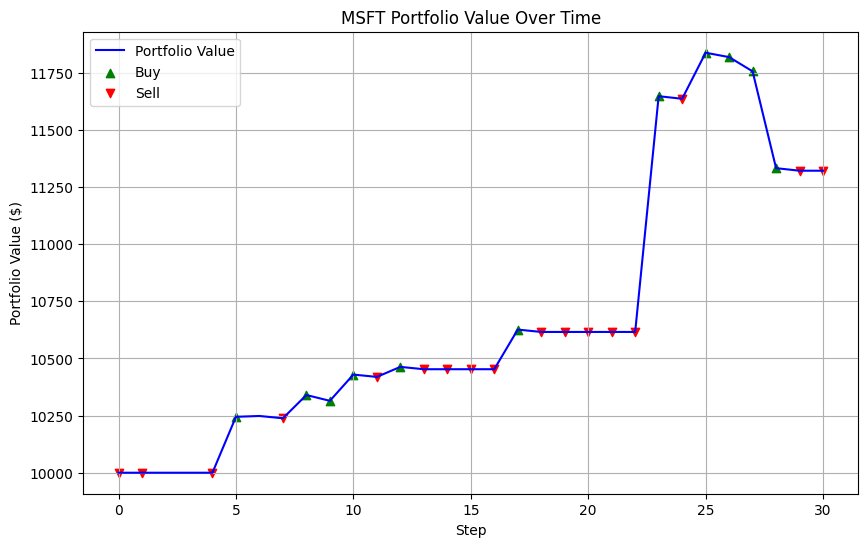

In [ ]:
#TRANSACTION COST: 0.1%

import numpy as np
import pandas as pd
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load stock symbol dynamically
with open("stock_symbol.txt", "r") as f:
    stock_symbol = f.read().strip()

filename = f"{stock_symbol}.csv"
print(f"\nUsing stock data file: {filename}")

class StockTradingEnv:
    def __init__(self, data_file, initial_balance=10000, transaction_cost=0.001):
        self.data = pd.read_csv(data_file)
        self.data['10_day_MA'] = self.data['Close'].rolling(window=10).mean().fillna(0)
        self.initial_balance = initial_balance
        self.balance = initial_balance
        self.shares = 0
        self.transaction_cost = transaction_cost
        self.current_step = 0
        self.holding_time = 0  # New for holding penalty
        self.close_min = self.data['Close'].min()
        self.close_max = self.data['Close'].max()
        self.volume_min = self.data['Volume'].min()
        self.volume_max = self.data['Volume'].max()
        self.ma_min = self.data['10_day_MA'].min()
        self.ma_max = self.data['10_day_MA'].max()

    def get_state(self):
        if self.current_step < len(self.data):
            state = [
                (self.data.loc[self.current_step, 'Close'] - self.close_min) / (self.close_max - self.close_min),
                (self.data.loc[self.current_step, 'Volume'] - self.volume_min) / (self.volume_max - self.volume_min),
                (self.data.loc[self.current_step, '10_day_MA'] - self.ma_min) / (self.ma_max - self.ma_min)
            ]
            return np.array(state)
        else:
            return np.zeros(3)

    def step(self, action):
        if self.current_step < len(self.data) - 1:
            old_portfolio = self.balance + self.shares * self.data.loc[self.current_step, 'Close']
            price = self.data.loc[self.current_step, 'Close']
            reward_bonus = 0  # Always initialize

            # Buy
            if action == 0:
                if self.balance > 0:
                    max_shares = int(self.balance / (price * (1 + self.transaction_cost)))
                    if max_shares > 0:
                        cost = max_shares * price * (1 + self.transaction_cost)
                        self.balance -= cost
                        self.shares += max_shares
                        self.holding_time = 0  # Reset holding time after buy

            # Sell
            elif action == 1:
                if self.shares > 0:
                    revenue = self.shares * price * (1 - self.transaction_cost)
                    self.balance += revenue
                    profit = (price - self.data.loc[self.current_step - 1, 'Close']) * self.shares
                    if profit > 0:
                        reward_bonus = 0.01
                    self.shares = 0
                    self.holding_time = 0

            # Hold
            else:
                if self.shares > 0:
                    self.holding_time += 1

            self.current_step += 1
            new_price = self.data.loc[self.current_step, 'Close']
            new_portfolio = self.balance + self.shares * new_price

            reward = (new_portfolio - old_portfolio) / old_portfolio

            if action in [0, 1]:
                reward -= 0.001

            reward += reward_bonus

            if self.holding_time > 20:
                reward -= 0.005

            done = self.current_step >= len(self.data) - 1
            return self.get_state(), reward, done, {}

        else:
            return np.zeros(3), 0, True, {}

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares = 0
        self.holding_time = 0
        return self.get_state()

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = tf.keras.Sequential([
            tf.keras.Input(shape=(self.state_size,)),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        return np.argmax(self.model.predict(state[np.newaxis, :], verbose=0)[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)

        states = np.array([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.array([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])

        target = rewards + (1 - dones) * self.gamma * np.amax(self.target_model.predict(next_states, verbose=0), axis=1)

        target_f = self.model.predict(states, verbose=0)
        for i in range(batch_size):
            target_f[i][actions[i]] = target[i]

        self.model.fit(states, target_f, epochs=1, verbose=0)


# Main training loop
env = StockTradingEnv(filename)
state_size = 3
action_size = 3
agent = DQNAgent(state_size, action_size)
num_episodes = 20
batch_size = 32

for e in tqdm(range(num_episodes), desc="Training Episodes"):
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        agent.replay(batch_size)
    print(f"Episode: {e+1}/{num_episodes}, Total Reward: {total_reward}")
    if (e+1) % 5 == 0:
        agent.update_target_model()
    agent.epsilon = max(agent.epsilon_min, agent.epsilon_decay * agent.epsilon)


# Testing with plotting
env.reset()
state = env.get_state()
done = False
total_profit = 0
portfolio_values = []
actions = []
steps = []

step = 0
while not done:
    agent.epsilon = 0
    action = agent.act(state)
    next_state, reward, done, _ = env.step(action)
    current_price = env.data.loc[env.current_step, 'Close']
    portfolio_value = env.balance + env.shares * current_price
    portfolio_values.append(portfolio_value)
    actions.append(action)
    steps.append(step)
    state = next_state
    total_profit += reward
    step += 1

print(f"Total profit in testing: {total_profit}")

trades = []
holding = False

for action in actions:
    if action == 0 and not holding:  # Buy
        trades.append('Buy')
        holding = True
    elif action == 1 and holding:    # Sell
        trades.append('Sell')
        holding = False

completed_trades = trades.count('Sell')  # Each Buy-Sell pair is one completed trade

print(f"Completed Trades (Buy-Sell Pairs): {completed_trades}")


plt.figure(figsize=(10, 6))
plt.plot(steps, portfolio_values, label='Portfolio Value', color='blue')
buy_steps = [s for s, a in zip(steps, actions) if a == 0]
sell_steps = [s for s, a in zip(steps, actions) if a == 1]
buy_values = [portfolio_values[i] for i, a in enumerate(actions) if a == 0]
sell_values = [portfolio_values[i] for i, a in enumerate(actions) if a == 1]

plt.scatter(buy_steps, buy_values, color='green', label='Buy', marker='^')
plt.scatter(sell_steps, sell_values, color='red', label='Sell', marker='v')
plt.xlabel('Step')
plt.ylabel('Portfolio Value ($)')
plt.title(f'{stock_symbol} Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# DQN Trading Metrics

final_portfolio_value = portfolio_values[-1]
true_profit = final_portfolio_value - 10000

trades = []
holding = False

for action in actions:
    if action == 0 and not holding:
        trades.append('Buy')
        holding = True
    elif action == 1 and holding:
        trades.append('Sell')
        holding = False

completed_trades = trades.count('Sell')

max_drawdown = max([max(portfolio_values[:i+1]) - min(portfolio_values[i:]) for i in range(len(portfolio_values))]) / 10000

daily_returns = [(portfolio_values[i] - portfolio_values[i-1]) / portfolio_values[i-1] for i in range(1, len(portfolio_values))]
avg_daily_return = np.mean(daily_returns) if daily_returns else 0
std_daily_return = np.std(daily_returns) if daily_returns else 0
risk_free_rate = 0.02 / 365
sharpe_ratio = (avg_daily_return - risk_free_rate) / std_daily_return if std_daily_return > 0 else 0

print(f"\nDQN Trading Performance Metrics")
print(f"Final Portfolio Value : {final_portfolio_value:.2f}")
print(f"True Profit           : {true_profit:.2f}")
print(f"Completed Trades      : {completed_trades}")
print(f"Max Drawdown          : {max_drawdown:.2%}")
print(f"Sharpe Ratio          : {sharpe_ratio:.2f}")



DQN Trading Performance Metrics
Final Portfolio Value : 11321.63
True Profit           : 1321.63
Completed Trades      : 6
Max Drawdown          : 5.16%
Sharpe Ratio          : 0.22


TRANSACTION COST 0.5%


Using stock data file: MSFT.csv


Training Episodes:   0%|          | 0/20 [00:00<?, ?it/s]

Episode: 1/20, Total Reward: -0.07170065032204145


Training Episodes:  10%|█         | 2/20 [00:08<01:16,  4.24s/it]

Episode: 2/20, Total Reward: -0.1137407783960146


...

Training Episodes:  95%|█████████▌| 19/20 [02:26<00:08,  8.01s/it]

Episode: 19/20, Total Reward: -0.024546374897127646


Training Episodes: 100%|██████████| 20/20 [02:35<00:00,  7.75s/it]

Episode: 20/20, Total Reward: -0.05665492688623226


Total profit in testing: -0.06832089012375744
Completed Trades (Buy-Sell Pairs): 0


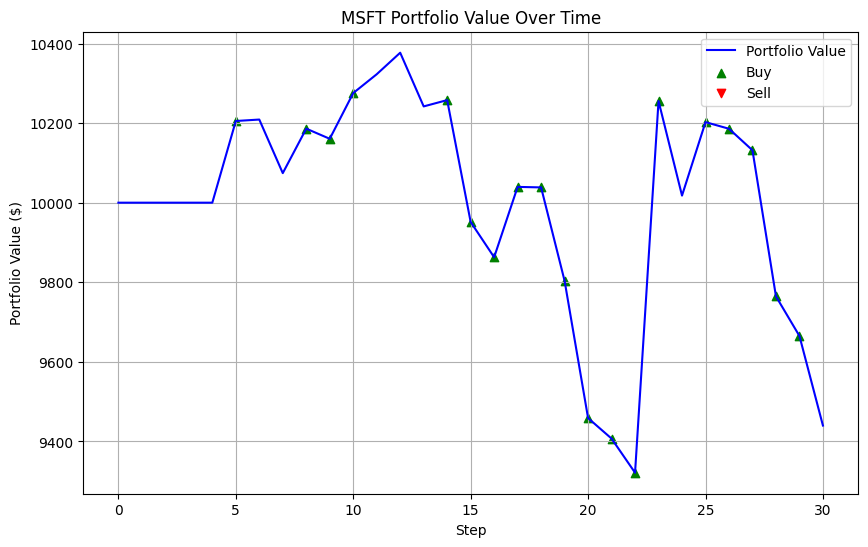

In [ ]:
#TRANSACTION COST: 0.5%

import numpy as np
import pandas as pd
import tensorflow as tf
from collections import deque
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

# Load stock symbol dynamically
with open("stock_symbol.txt", "r") as f:
    stock_symbol = f.read().strip()

filename = f"{stock_symbol}.csv"
print(f"\nUsing stock data file: {filename}")

class StockTradingEnv:
    def __init__(self, data_file, initial_balance=10000, transaction_cost=0.005):
        self.data = pd.read_csv(data_file)
        self.data['10_day_MA'] = self.data['Close'].rolling(window=10).mean().fillna(0)
        self.initial_balance = initial_balance
        self.balance = initial_balance
        self.shares = 0
        self.transaction_cost = transaction_cost
        self.current_step = 0
        self.holding_time = 0  # New for holding penalty
        self.close_min = self.data['Close'].min()
        self.close_max = self.data['Close'].max()
        self.volume_min = self.data['Volume'].min()
        self.volume_max = self.data['Volume'].max()
        self.ma_min = self.data['10_day_MA'].min()
        self.ma_max = self.data['10_day_MA'].max()

    def get_state(self):
        if self.current_step < len(self.data):
            state = [
                (self.data.loc[self.current_step, 'Close'] - self.close_min) / (self.close_max - self.close_min),
                (self.data.loc[self.current_step, 'Volume'] - self.volume_min) / (self.volume_max - self.volume_min),
                (self.data.loc[self.current_step, '10_day_MA'] - self.ma_min) / (self.ma_max - self.ma_min)
            ]
            return np.array(state)
        else:
            return np.zeros(3)

    def step(self, action):
        if self.current_step < len(self.data) - 1:
            old_portfolio = self.balance + self.shares * self.data.loc[self.current_step, 'Close']
            price = self.data.loc[self.current_step, 'Close']
            reward_bonus = 0  # Always initialize

            # Buy
            if action == 0:
                if self.balance > 0:
                    max_shares = int(self.balance / (price * (1 + self.transaction_cost)))
                    if max_shares > 0:
                        cost = max_shares * price * (1 + self.transaction_cost)
                        self.balance -= cost
                        self.shares += max_shares
                        self.holding_time = 0  # Reset holding time after buy

            # Sell
            elif action == 1:
                if self.shares > 0:
                    revenue = self.shares * price * (1 - self.transaction_cost)
                    self.balance += revenue
                    profit = (price - self.data.loc[self.current_step - 1, 'Close']) * self.shares
                    if profit > 0:
                        reward_bonus = 0.01
                    self.shares = 0
                    self.holding_time = 0

            # Hold
            else:
                if self.shares > 0:
                    self.holding_time += 1

            self.current_step += 1
            new_price = self.data.loc[self.current_step, 'Close']
            new_portfolio = self.balance + self.shares * new_price

            reward = (new_portfolio - old_portfolio) / old_portfolio

            if action in [0, 1]:
                reward -= 0.001

            reward += reward_bonus

            if self.holding_time > 20:
                reward -= 0.005

            done = self.current_step >= len(self.data) - 1
            return self.get_state(), reward, done, {}

        else:
            return np.zeros(3), 0, True, {}

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.shares = 0
        self.holding_time = 0
        return self.get_state()

class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = tf.keras.Sequential([
            tf.keras.Input(shape=(self.state_size,)),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        return np.argmax(self.model.predict(state[np.newaxis, :], verbose=0)[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return
        minibatch = random.sample(self.memory, batch_size)

        states = np.array([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.array([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])

        target = rewards + (1 - dones) * self.gamma * np.amax(self.target_model.predict(next_states, verbose=0), axis=1)

        target_f = self.model.predict(states, verbose=0)
        for i in range(batch_size):
            target_f[i][actions[i]] = target[i]

        self.model.fit(states, target_f, epochs=1, verbose=0)


# Main training loop
env = StockTradingEnv(filename)
state_size = 3
action_size = 3
agent = DQNAgent(state_size, action_size)
num_episodes = 20
batch_size = 32

for e in tqdm(range(num_episodes), desc="Training Episodes"):
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = agent.act(state)
        next_state, reward, done, _ = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        agent.replay(batch_size)
    print(f"Episode: {e+1}/{num_episodes}, Total Reward: {total_reward}")
    if (e+1) % 5 == 0:
        agent.update_target_model()
    agent.epsilon = max(agent.epsilon_min, agent.epsilon_decay * agent.epsilon)


# Testing with plotting
env.reset()
state = env.get_state()
done = False
total_profit = 0
portfolio_values = []
actions = []
steps = []

step = 0
while not done:
    agent.epsilon = 0
    action = agent.act(state)
    next_state, reward, done, _ = env.step(action)
    current_price = env.data.loc[env.current_step, 'Close']
    portfolio_value = env.balance + env.shares * current_price
    portfolio_values.append(portfolio_value)
    actions.append(action)
    steps.append(step)
    state = next_state
    total_profit += reward
    step += 1

print(f"Total profit in testing: {total_profit}")

trades = []
holding = False

for action in actions:
    if action == 0 and not holding:  # Buy
        trades.append('Buy')
        holding = True
    elif action == 1 and holding:    # Sell
        trades.append('Sell')
        holding = False

completed_trades = trades.count('Sell')  # Each Buy-Sell pair is one completed trade

print(f"Completed Trades (Buy-Sell Pairs): {completed_trades}")


plt.figure(figsize=(10, 6))
plt.plot(steps, portfolio_values, label='Portfolio Value', color='blue')
buy_steps = [s for s, a in zip(steps, actions) if a == 0]
sell_steps = [s for s, a in zip(steps, actions) if a == 1]
buy_values = [portfolio_values[i] for i, a in enumerate(actions) if a == 0]
sell_values = [portfolio_values[i] for i, a in enumerate(actions) if a == 1]

plt.scatter(buy_steps, buy_values, color='green', label='Buy', marker='^')
plt.scatter(sell_steps, sell_values, color='red', label='Sell', marker='v')
plt.xlabel('Step')
plt.ylabel('Portfolio Value ($)')
plt.title(f'{stock_symbol} Portfolio Value Over Time')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# DQN Trading Metrics

final_portfolio_value = portfolio_values[-1]
true_profit = final_portfolio_value - 10000

trades = []
holding = False

for action in actions:
    if action == 0 and not holding:
        trades.append('Buy')
        holding = True
    elif action == 1 and holding:
        trades.append('Sell')
        holding = False

completed_trades = trades.count('Sell')

max_drawdown = max([max(portfolio_values[:i+1]) - min(portfolio_values[i:]) for i in range(len(portfolio_values))]) / 10000

daily_returns = [(portfolio_values[i] - portfolio_values[i-1]) / portfolio_values[i-1] for i in range(1, len(portfolio_values))]
avg_daily_return = np.mean(daily_returns) if daily_returns else 0
std_daily_return = np.std(daily_returns) if daily_returns else 0
risk_free_rate = 0.02 / 365
sharpe_ratio = (avg_daily_return - risk_free_rate) / std_daily_return if std_daily_return > 0 else 0

print(f"\nDQN Trading Performance Metrics")
print(f"Final Portfolio Value : {final_portfolio_value:.2f}")
print(f"True Profit           : {true_profit:.2f}")
print(f"Completed Trades      : {completed_trades}")
print(f"Max Drawdown          : {max_drawdown:.2%}")
print(f"Sharpe Ratio          : {sharpe_ratio:.2f}")



DQN Trading Performance Metrics
Final Portfolio Value : 9439.86
True Profit           : -560.14
Completed Trades      : 0
Max Drawdown          : 10.56%
Sharpe Ratio          : -0.07
